# Weather Forecasting Project with CGAN Imputation, VARMA/CVARMA Forecasting & Rain Prediction

# ---------------------------------------------
# 1. Install and Import Required Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow statsmodels flask

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import tensorflow as tf
from tensorflow.keras import layers
import requests
import time
from flask import Flask, render_template_string
import threading



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 2. Load and Preprocess the Dataset

In [2]:
df_bangalore = pd.read_csv("Bangalore_1990_2022_BangaloreCity.csv")
df_delhi = pd.read_csv("Delhi_NCR_1990_2022_Safdarjung.csv")

def preprocess(df):
    df = df.rename(columns=lambda x: x.strip().replace(" ", "_"))
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    df = df.dropna(subset=['time'])
    df = df.set_index('time') # Explicitly set the datetime column as index
    numeric_cols = df.select_dtypes(include=np.number).columns
    df[numeric_cols] = df[numeric_cols].replace(0, np.nan)
    return df[numeric_cols]

df_b = preprocess(df_bangalore)
df_d = preprocess(df_delhi)

#3. Normalize Data & Create Mask for Missing Values

this code prepares the data for imputation by normalizing the numerical features and creating a mask to keep track of the original missing values, which were temporarily replaced by zeros for the normalization step. The scaler is also saved to potentially inverse transform the data later.

In [3]:
def normalize_and_mask(df):
    mask = ~df.isna().values
    scaler = StandardScaler()
    norm_data = scaler.fit_transform(np.nan_to_num(df.values))
    return norm_data, mask, scaler

data_b, mask_b, scaler_b = normalize_and_mask(df_b)
data_d, mask_d, scaler_d = normalize_and_mask(df_d)

# 4. CGAN Architecture & Training Function

In [4]:
def build_generator(input_dim, cond_dim):
    return tf.keras.Sequential([
        layers.Input(shape=(input_dim + cond_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(input_dim)
    ])

def build_discriminator(input_dim, cond_dim):
    return tf.keras.Sequential([
        layers.Input(shape=(input_dim + cond_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

def train_cgan(data, mask, epochs=300, batch_size=64):
    input_dim = data.shape[1]
    G = build_generator(input_dim, input_dim)
    D = build_discriminator(input_dim, input_dim)
    opt_G = tf.keras.optimizers.Adam(0.001)
    opt_D = tf.keras.optimizers.Adam(0.001)
    loss_fn = tf.keras.losses.BinaryCrossentropy()

    for epoch in range(epochs):
        idx = np.random.randint(0, data.shape[0], batch_size)
        real = data[idx]
        mask_sample = mask[idx]
        noise = tf.random.normal((batch_size, input_dim))
        cond = tf.convert_to_tensor(real * mask_sample, dtype=tf.float32)
        gen_input = tf.concat([noise, cond], axis=1)
        fake = G(gen_input)

        real_input = tf.concat([tf.convert_to_tensor(real, dtype=tf.float32), cond], axis=1)
        fake_input = tf.concat([fake, cond], axis=1)

        with tf.GradientTape() as tape_D:
            D_real = D(real_input)
            D_fake = D(fake_input)
            D_loss = loss_fn(tf.ones_like(D_real), D_real) + loss_fn(tf.zeros_like(D_fake), D_fake)
        grads_D = tape_D.gradient(D_loss, D.trainable_variables)
        opt_D.apply_gradients(zip(grads_D, D.trainable_variables))

        with tf.GradientTape() as tape_G:
            fake = G(gen_input)
            fake_input = tf.concat([fake, cond], axis=1)
            D_fake = D(fake_input)
            G_loss = loss_fn(tf.ones_like(D_fake), D_fake)
        grads_G = tape_G.gradient(G_loss, G.trainable_variables)
        opt_G.apply_gradients(zip(grads_G, G.trainable_variables))

        if epoch % 50 == 0:
            print(f"Epoch {epoch}, G Loss: {G_loss.numpy():.4f}, D Loss: {D_loss.numpy():.4f}")

    return G

# 5. Train CGAN and Impute Missing Data

In [5]:
generator_b = train_cgan(data_b, mask_b)
noise_b = tf.random.normal((data_b.shape[0], data_b.shape[1]))
cond_b = tf.convert_to_tensor(data_b * mask_b, dtype=tf.float32)
gen_input_b = tf.concat([noise_b, cond_b], axis=1)
imputed_b = generator_b(gen_input_b).numpy()
final_b = np.where(mask_b, data_b, imputed_b)
df_b_imputed = pd.DataFrame(scaler_b.inverse_transform(final_b), columns=df_b.columns)

generator_d = train_cgan(data_d, mask_d)
noise_d = tf.random.normal((data_d.shape[0], data_d.shape[1]))
cond_d = tf.convert_to_tensor(data_d * mask_d, dtype=tf.float32)
gen_input_d = tf.concat([noise_d, cond_d], axis=1)
imputed_d = generator_d(gen_input_d).numpy()
final_d = np.where(mask_d, data_d, imputed_d)
df_d_imputed = pd.DataFrame(scaler_d.inverse_transform(final_d), columns=df_d.columns)

Epoch 0, G Loss: 0.6969, D Loss: 1.3741
Epoch 50, G Loss: 0.8692, D Loss: 1.1255
Epoch 100, G Loss: 1.2341, D Loss: 0.9607
Epoch 150, G Loss: 1.2236, D Loss: 1.1736
Epoch 200, G Loss: 0.8681, D Loss: 1.2113
Epoch 250, G Loss: 0.7052, D Loss: 1.4948
Epoch 0, G Loss: 0.6785, D Loss: 1.4123
Epoch 50, G Loss: 0.7854, D Loss: 1.2002
Epoch 100, G Loss: 0.9694, D Loss: 1.2297
Epoch 150, G Loss: 0.8226, D Loss: 1.3372
Epoch 200, G Loss: 0.7008, D Loss: 1.3567
Epoch 250, G Loss: 0.6970, D Loss: 1.3543


# 6. Forecast Weather Using VARMA

In [ ]:
model_varma_b = VARMAX(df_b_imputed[['tavg', 'prcp']], order=(2, 1))
results_varma_b = model_varma_b.fit(disp=False, maxiter=1000)

model_varma_d = VARMAX(df_d_imputed[['tavg', 'prcp']], order=(2, 1))
results_varma_d = model_varma_d.fit(disp=False, maxiter=1000)

c:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
c:\Users\A\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


# 7. Rain Prediction using Random Forest

In [ ]:
df_b_imputed['Rain_Today'] = (df_b_imputed['prcp'] > 0).astype(int)
features_b = df_b_imputed[['tavg']] # Train only on 'tavg'
target_b = df_b_imputed['Rain_Today']
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(features_b, target_b, test_size=0.2, shuffle=False)
clf_b = RandomForestClassifier()
clf_b.fit(X_train_b, y_train_b)
y_pred_b = clf_b.predict(X_test_b)
print("Bangalore Rain Prediction:\n", classification_report(y_test_b, y_pred_b))
rain_pred_b = clf_b.predict(forecast_varma_b[['tavg']]) # Predict using only 'tavg' from forecast

df_d_imputed['Rain_Today'] = (df_d_imputed['prcp'] > 0).astype(int)
features_d = df_d_imputed[['tavg']] # Train only on 'tavg'
target_d = df_d_imputed['Rain_Today']
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(features_d, target_d, test_size=0.2, shuffle=False)
clf_d = RandomForestClassifier()
clf_d.fit(X_train_d, y_train_d)
y_pred_d = clf_d.predict(X_test_d)
print("Delhi Rain Prediction:\n", classification_report(y_test_d, y_pred_d))
rain_pred_d = clf_d.predict(forecast_varma_d[['tavg']]) # Predict using only 'tavg' from forecast

Bangalore Rain Prediction:
               precision    recall  f1-score   support

           0       0.43      0.10      0.16       286
           1       0.70      0.94      0.81       653

    accuracy                           0.68       939
   macro avg       0.57      0.52      0.48       939
weighted avg       0.62      0.68      0.61       939

Delhi Rain Prediction:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.96      1.00      0.98       898

    accuracy                           0.95       939
   macro avg       0.48      0.50      0.49       939
weighted avg       0.91      0.95      0.93       939



## Explanation of Rain Prediction Bar Plot

These bar plots show the binary rain prediction (Rain: 1, No Rain: 0) for the next 10 days for Bangalore and Delhi. Each bar represents a day, and the height of the bar indicates whether rain is predicted (1) or not (0). Please note that this is a binary prediction and does not indicate the intensity or type of rain. There is also an issue with the plot displaying dates in 2025 instead of the current year.

/tmp/ipython-input-3646845327.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Date', y='Rain_Prediction', data=rain_forecast_b_df, palette='viridis')
/tmp/ipython-input-3646845327.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Date', y='Rain_Prediction', data=rain_forecast_d_df, palette='viridis')


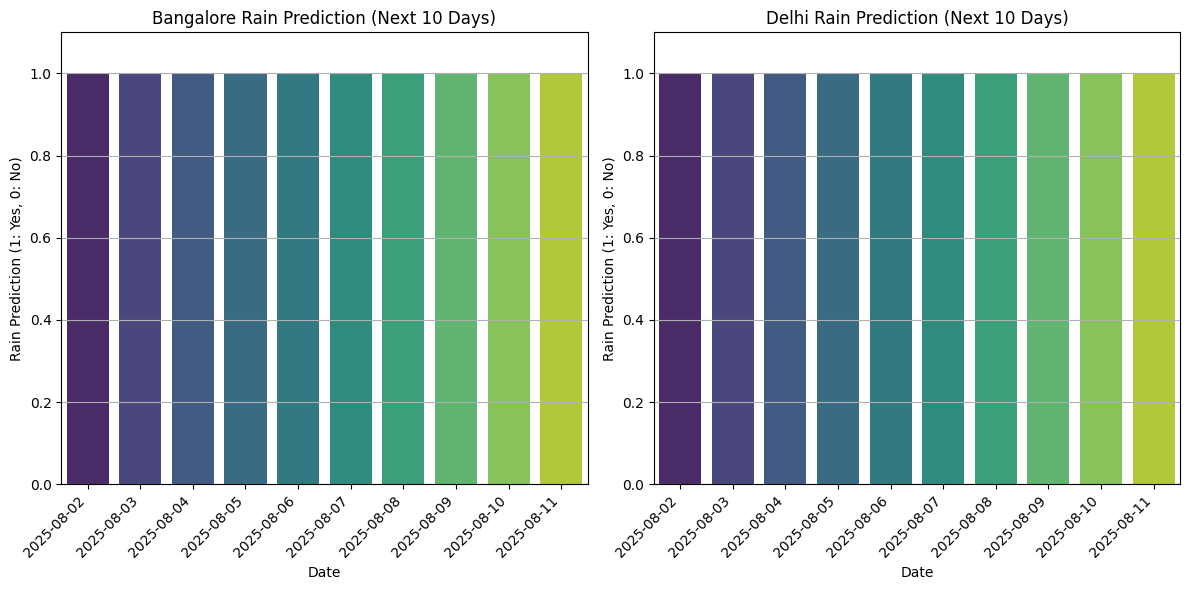

In [ ]:
from datetime import date

# Get today's date
today = date.today()

# Generate forecast dates starting from today for the next 10 days
forecast_dates = pd.date_range(start=today, periods=10, freq='D')

# Create dataframes for rain predictions with correct dates
# Ensure the index is reset or ignore it, and use the generated forecast_dates for the 'Date' column
rain_forecast_b_df = pd.DataFrame({'Date': forecast_dates, 'Rain_Prediction': rain_pred_b})
rain_forecast_d_df = pd.DataFrame({'Date': forecast_dates, 'Rain_Prediction': rain_pred_d})

# Visualize rain predictions
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Date', y='Rain_Prediction', data=rain_forecast_b_df, palette='viridis')
plt.title('Bangalore Rain Prediction (Next 10 Days)')
plt.ylabel('Rain Prediction (1: Yes, 0: No)')
plt.xlabel('Date')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1) # Set y-axis limits to clearly show 0 and 1
plt.grid(axis='y')

plt.subplot(1, 2, 2)
sns.barplot(x='Date', y='Rain_Prediction', data=rain_forecast_d_df, palette='viridis')
plt.title('Delhi Rain Prediction (Next 10 Days)')
plt.ylabel('Rain Prediction (1: Yes, 0: No)')
plt.xlabel('Date')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1) # Set y-axis limits to clearly show 0 and 1
plt.grid(axis='y')

plt.tight_layout()
plt.show()

# 8. ThingSpeak Integration (Optional)

In [ ]:
THINGSPEAK_API_KEY = '2W222XHH7S8NBZAT'
def upload_to_thingspeak(dataframe):
    for idx, row in dataframe.iterrows():
        payload = {
            'api_key': THINGSPEAK_API_KEY,
            'field1': row.get('tmin', ''),
            'field2': row.get('tavg', ''),
            'field3': row.get('tmax', ''),
            'field4': row.get('prcp', '')
        }
        r = requests.get("https://api.thingspeak.com/update", params=payload)
        print(f"Uploaded row {idx+1}, status: {r.status_code}")
        time.sleep(15)  # API rate limit

# 9. Upload Imputed Data to ThingSpeak

This code calls the `upload_to_thingspeak` function defined earlier to send the imputed weather data for Bangalore to your configured ThingSpeak channel.

In [ ]:
# Call the function to upload data to ThingSpeak (using the first 5 rows of Bangalore data as an example)
upload_to_thingspeak(df_b_imputed[['tmin', 'tavg', 'tmax', 'prcp']].head(5))

Uploaded row 1, status: 200
Uploaded row 2, status: 200
Uploaded row 3, status: 200
Uploaded row 4, status: 200
Uploaded row 5, status: 200


# 9. Flask Dashboard for Forecast

In [ ]:
app = Flask(__name__)
run_with_ngrok(app) # Start ngrok when app is run

@app.route("/")
def dashboard():
    data = list(zip(
        pd.date_range(df_b_imputed.index[-1] + pd.Timedelta(days=1), periods=10, freq='D').strftime('%Y-%m-%d'),
        forecast_varma_b['tavg'].round(2).tolist(),
        ["Yes" if r == 1 else "No" for r in rain_pred_b]
    ))
    return render_template_string('''
    <!DOCTYPE html>
    <html>
    <head>
        <title>Bangalore Forecast Dashboard</title>
        <style>
            body {
                font-family: sans-serif;
                background-color: #f4f4f4;
                margin: 20px;
            }
            h2 {
                color: #333;
                text-align: center;
                margin-bottom: 20px;
            }
            table {
                border-collapse: collapse;
                width: 80%;
                margin: 0 auto;
                background-color: #fff;
                box-shadow: 0 2px 5px rgba(0,0,0,0.1);
            }
            th, td {
                padding: 12px 15px;
                text-align: left;
                border-bottom: 1px solid #ddd;
            }
            th {
                background-color: #4CAF50;
                color: white;
            }
            tr:hover {
                background-color: #f5f5f5;
            }
            tr:nth-child(even) {
                background-color: #f9f9f9;
            }
        </style>
    </head>
    <body>
        <h2>Bangalore Forecast Dashboard</h2>
        <table>
            <tr><th>Date</th><th>Temperature Avg (°C)</th><th>Will it Rain?</th></tr>
            {% for d, t, r in data %}
              <tr><td>{{ d }}</td><td>{{ t }}</td><td>{{ r }}</td></tr>
            {% endfor %}
        </table>
    </body>
    </html>
    ''', data=data)